# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [1]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Dominik Caleb Moreno Hernández"            # Tu nombre completo
MATRICULA = "81928"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "desnutricion"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Dominik Caleb Moreno Hernández
Matrícula: 81928
Dataset asignado: desnutricion


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [2]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\domin\Desktop\Tareas Uni\Semestre 5\Tópicos de Big Data\U1_1_probabilidad_estadistica\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: desnutricion
Descripcion: Numero de personas subalimentadas (desnutricion) (personas)


In [4]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [5]:
df.head(25)

,entity,code,year,valor
0,Afghanistan,AFG,2001,9400000.0
1,Afghanistan,AFG,2002,9300000.0
2,Afghanistan,AFG,2003,8700000.0
3,Afghanistan,AFG,2004,8200000.0
4,Afghanistan,AFG,2005,7500000.0
5,Afghanistan,AFG,2006,6700000.0
6,Afghanistan,AFG,2007,5900000.0
7,Afghanistan,AFG,2008,5200000.0
8,Afghanistan,AFG,2009,4800000.0
9,Afghanistan,AFG,2010,5000000.0


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [6]:
# Forma del dataset (filas, columnas)
df.shape


(3544, 4)

In [7]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3544 entries, 0 to 3543
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  3544 non-null   str    
 1   code    2758 non-null   str    
 2   year    3544 non-null   int64  
 3   valor   3544 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 110.9 KB


In [8]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    3.544000e+03
mean     3.061574e+07
std      8.749230e+07
min      1.000000e+05
25%      3.000000e+05
50%      2.100000e+06
75%      9.925000e+06
max      8.252000e+08
Name: valor, dtype: float64

In [9]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity      0
code      786
year        0
valor       0
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

Los únicos valores nulos están en la columna code (786 de 3544 filas), mientras que entity, year y valor están completas; esto sugiere que hay filas de agregados (regiones, continentes, mundo) que no tienen un código de país asignado. En las filas mostradas con df.head(25) los años van de 2000 a 2023. Valor es una variable numérica continua (float64), con un rango muy amplio, lo que indica que se trata de un conteo absoluto de personas y no de un porcentaje o tasa.

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [10]:
# Pregunta 1
df_paises = df.loc[df[config["filtro_paises"]].notnull() & ~df[config["filtro_paises"]].str.startswith("OWID_")]  #Esto se tuvo que agregar debido a que World tiene un código pero en las instrucciones nos pide descartarlo de los países reales

n_paises = df_paises["entity"].nunique()
print(f"Países distintos: {n_paises}")

top_10 = df_paises.sort_values("valor", ascending=False).head(10)
bottom_10 = df_paises.sort_values("valor", ascending=True).head(10)

print("\nTop 10 países con mayor valor:")
print(top_10[["entity", "year", "valor"]])

print("\nTop 10 países con menor valor:")
print(bottom_10[["entity", "year", "valor"]])


Países distintos: 139

Top 10 países con mayor valor:
     entity  year        valor
1341  India  2004  247000000.0
1342  India  2005  243900000.0
1340  India  2003  236800000.0
1343  India  2006  222200000.0
1339  India  2002  216300000.0
1358  India  2021  201900000.0
1344  India  2007  197200000.0
1338  India  2001  194900000.0
1359  India  2022  192000000.0
1357  India  2020  188400000.0

Top 10 países con menor valor:
       entity  year     valor
3339  Vanuatu  2006  100000.0
3338  Vanuatu  2005  100000.0
3337  Vanuatu  2004  100000.0
3336  Vanuatu  2003  100000.0
3335  Vanuatu  2002  100000.0
64    Albania  2017  100000.0
63    Albania  2016  100000.0
62    Albania  2015  100000.0
61    Albania  2014  100000.0
60    Albania  2013  100000.0


**Interpretación:**

Al filtrar los países usando la columna code y excluir códigos de países no reales como World, nos quedan 139 países reales. En el top 10 de mayor valor (más personas con desnutrición) solo aparece India con distintos años entre 2001 y 2022 (su máximo fue en 2004, con 247 millones de personas). En el top 10 de menor valor (menos personas con desnutrición) aparecen Vanuatu ( 2002-2006) y Albania (2013-2017), ambos con el valor mínimo de 100,000 personas.

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés `Nigeria`) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [11]:
# Pregunta 2

mexico = df_paises[df_paises["entity"] == "Mexico"]
nigeria = df_paises[df_paises["entity"] == "Nigeria"]

anio_inicio = max(mexico["year"].min(), nigeria["year"].min())
anio_fin = min(mexico["year"].max(), nigeria["year"].max())
print(f"Rango de años disponible para ambos: {anio_inicio} - {anio_fin}")

mexico_rango = mexico[(mexico["year"] >= anio_inicio) & (mexico["year"] <= anio_fin)]
nigeria_rango = nigeria[(nigeria["year"] >= anio_inicio) & (nigeria["year"] <= anio_fin)]

print("\nMéxico:")
print(mexico_rango[["entity", "year", "valor"]])

print("\nNigeria:")
print(nigeria_rango[["entity", "year", "valor"]])


Rango de años disponible para ambos: 2001 - 2023

México:
      entity  year      valor
1964  Mexico  2001  2800000.0
1965  Mexico  2002  3300000.0
1966  Mexico  2003  3900000.0
1967  Mexico  2004  4300000.0
1968  Mexico  2005  4200000.0
1969  Mexico  2006  4000000.0
1970  Mexico  2007  4000000.0
1971  Mexico  2008  4400000.0
1972  Mexico  2009  4600000.0
1973  Mexico  2010  4600000.0
1974  Mexico  2011  4400000.0
1975  Mexico  2012  4500000.0
1976  Mexico  2013  4400000.0
1977  Mexico  2014  4500000.0
1978  Mexico  2015  4400000.0
1979  Mexico  2016  4500000.0
1980  Mexico  2017  4600000.0
1981  Mexico  2018  4500000.0
1982  Mexico  2019  4300000.0
1983  Mexico  2020  3900000.0
1984  Mexico  2021  3800000.0
1985  Mexico  2022  3600000.0
1986  Mexico  2023  3500000.0

Nigeria:
       entity  year       valor
2238  Nigeria  2001  11300000.0
2239  Nigeria  2002  11600000.0
2240  Nigeria  2003  12100000.0
2241  Nigeria  2004  12600000.0
2242  Nigeria  2005  13200000.0
2243  Nigeria  2006 

### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [12]:
# Pregunta 3
paises_interes = ["Mexico", "Nigeria", "India", "Albania", "Vanuatu"]

anio_reciente = df_paises["year"].max()
print(f"Año más reciente disponible: {anio_reciente}")

comparacion = df_paises[(df_paises["entity"].isin(paises_interes)) & (df_paises["year"] == anio_reciente)]
comparacion = comparacion.sort_values("valor", ascending=False)
print(comparacion[["entity", "valor"]])

pais_max = comparacion.iloc[0]
pais_min = comparacion.iloc[-1]
diferencia = pais_max["valor"] - pais_min["valor"]

print(f"\nValor más alto: {pais_max['entity']} ({pais_max['valor']:,.0f})")
print(f"Valor más bajo: {pais_min['entity']} ({pais_min['valor']:,.0f})")
print(f"Diferencia: {diferencia:,.0f}")


Año más reciente disponible: 2023
       entity        valor
1360    India  172100000.0
2260  Nigeria   45400000.0
1986   Mexico    3500000.0
70    Albania     200000.0
3356  Vanuatu     100000.0

Valor más alto: India (172,100,000)
Valor más bajo: Vanuatu (100,000)
Diferencia: 172,000,000


**Interpretación:**

Comparando cinco países de distintos continentes (México, Nigeria, Albania, India y Vanuatu) en el año más reciente disponible (2023), el valor más alto lo tiene India con 172,100,000 personas subalimentadas (con desnutrición), y el más bajo lo tiene Vanuatu con 100,000 personas con desnutrición (esto ya lo habíamos visto en el top 10 de países con menos personas subalimentadas). Esto nos da una diferencia de 172,000,000 personas. Esta brecha tan grande refleja principalmente el tamaño de población de cada país y no necesariamente indica que Vanuatu tenga menos desnutrición que India.


### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [13]:
# Pregunta 4
latinoamerica = ["Mexico", "Colombia", "Argentina"]
asia = ["Indonesia", "Thailand", "Vietnam"]

anio_reciente = df_paises["year"].max()
print(f"Año más reciente disponible: {anio_reciente}")

grupo_latam = df_paises[(df_paises["entity"].isin(latinoamerica)) & (df_paises["year"] == anio_reciente)]
grupo_asia = df_paises[(df_paises["entity"].isin(asia)) & (df_paises["year"] == anio_reciente)]

print("\nLatinoamérica:")
print(grupo_latam[["entity", "valor"]])
promedio_latam = grupo_latam["valor"].mean()
print(f"Promedio Latinoamérica: {promedio_latam:,.0f}")

print("\nAsia:")
print(grupo_asia[["entity", "valor"]])
promedio_asia = grupo_asia["valor"].mean()
print(f"Promedio Asia: {promedio_asia:,.0f}")


Año más reciente disponible: 2023

Latinoamérica:
         entity      valor
158   Argentina  1500000.0
663    Colombia  2000000.0
1986     Mexico  3500000.0
Promedio Latinoamérica: 2,333,333

Asia:
         entity       valor
1383  Indonesia  17700000.0
3147   Thailand   3300000.0
3397    Vietnam   5300000.0
Promedio Asia: 8,766,667


**Interpretación:**

En 2023, el promedio de personas subalimentadas en el grupo de Latinoamérica (México, Colombia, Argentina) fue de aproximadamente 2,333,333 personas, mientras que en el grupo de Asia (Indonesia, Tailandia, Vietnam) fue de 8,766,667 personas, casi 4 veces más alto. Esta diferencia se explica sobre todo porque los países asiáticos elegidos tienen poblaciones mucho más grandes que los latinoamericanos (en especial Indonesia), por lo que de nuevo el indicador absoluto favorece a los países con menos habitantes y no siempre refleja una peor situación nutricional relativa.

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [14]:
# Pregunta 5

df_pais = df_paises[df_paises["entity"] == "Nigeria"]

anio_min = df_pais.loc[df_pais["valor"].idxmin(), "year"]
anio_max = df_pais.loc[df_pais["valor"].idxmax(), "year"]
valor_min = df_pais["valor"].min()
valor_max = df_pais["valor"].max()

print(f"Valor mínimo: {valor_min:,.0f} en el año {anio_min}")
print(f"Valor máximo: {valor_max:,.0f} en el año {anio_max}")
print(df_pais[["year", "valor"]])


Valor mínimo: 11,300,000 en el año 2001
Valor máximo: 45,400,000 en el año 2023
      year       valor
2238  2001  11300000.0
2239  2002  11600000.0
2240  2003  12100000.0
2241  2004  12600000.0
2242  2005  13200000.0
2243  2006  13800000.0
2244  2007  14400000.0
2245  2008  15100000.0
2246  2009  16000000.0
2247  2010  17400000.0
2248  2011  19000000.0
2249  2012  20600000.0
2250  2013  20700000.0
2251  2014  20600000.0
2252  2015  20300000.0
2253  2016  21100000.0
2254  2017  23100000.0
2255  2018  24900000.0
2256  2019  29900000.0
2257  2020  33800000.0
2258  2021  38600000.0
2259  2022  41700000.0
2260  2023  45400000.0


**Interpretación:**

Para Nigeria, el valor mínimo se registró en 2001 (11,300,000 personas) y el máximo en 2023 (45,400,000 personas). La tendencia general es claramente creciente: el número de personas subalimentadas solo aumentó en 23 años, con un breve estancamiento entre 2013 y 2015 pero continuó con un crecimiento sostenido desde 2016 hasta 2023.

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [15]:
# Pregunta 6
df_pais = df_paises[df_paises["entity"] == "Mexico"].sort_values("year")

anio_inicial = df_pais["year"].min()
anio_final = df_pais["year"].max()

valor_inicial = df_pais.loc[df_pais["year"] == anio_inicial, "valor"].values[0]
valor_final = df_pais.loc[df_pais["year"] == anio_final, "valor"].values[0]

cambio_porcentual = (valor_final - valor_inicial) / valor_inicial * 100

print(f"Valor en {anio_inicial}: {valor_inicial:,.0f}")
print(f"Valor en {anio_final}: {valor_final:,.0f}")
print(f"Cambio porcentual: {cambio_porcentual:.2f}%")


Valor en 2001: 2,800,000
Valor en 2023: 3,500,000
Cambio porcentual: 25.00%


**Interpretación:**

Entre 2001 y 2023, el número de personas subalimentadas en México pasó de 2,800,000 a 3,500,000 personas, un incremento relativo del 25%. Aunque parece un resultado negativo, este dato no muestra por completo la realidad ya que valor es un conteo absoluto por lo que no toma en cuenta que en ese mismo periodo la población de México también creció. Además, existen diversos factor como la pandemia que pueden afectar el incremento de valor.

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [16]:
# Pregunta 7
anio_reciente = df_paises["year"].max()

valores_reciente = df_paises.loc[df_paises["year"] == anio_reciente, "valor"].to_numpy()
valores_reciente = valores_reciente[~np.isnan(valores_reciente)]

media = np.mean(valores_reciente)
mediana = np.median(valores_reciente)
desviacion_estandar = np.std(valores_reciente)

print(f"Año más reciente: {anio_reciente}")
print(f"Cantidad de países considerados: {len(valores_reciente)}")
print(f"Media: {media:,.2f}")
print(f"Mediana: {mediana:,.2f}")
print(f"Desviación estándar: {desviacion_estandar:,.2f}")


Año más reciente: 2023
Cantidad de países considerados: 105
Media: 5,884,761.90
Mediana: 1,600,000.00
Desviación estándar: 18,150,375.99


**Interpretación:**

Para 2023, de los 105 países reales con dato disponible ese año, la media es de 5,884,761.90 personas subalimentadas, pero la mediana es de solo 1,600,000. Esta gran diferencia entre media y mediana indica una distribución muy sesgada. La mayoría de los países tienen valores relativamente bajos, pero unos pocos países muy poblados (como India) tienen cifras enormes que "jalan" la media hacia arriba. La desviación estándar (18,150,375.99), más de 3 veces la media, confirma esta gran dispersión.

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

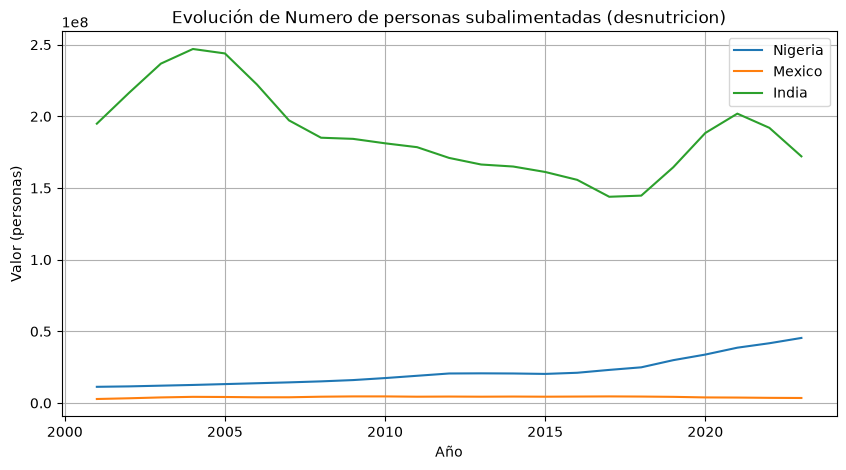

In [17]:
# Pregunta 8
paises_grafica = ["Nigeria", "Mexico", "India"]

plt.figure(figsize=(10, 5))

for pais in paises_grafica:
    df_pais = df_paises[df_paises["entity"] == pais].sort_values("year")
    plt.plot(df_pais["year"], df_pais["valor"], label=pais)

plt.title(f"Evolución de {config['descripcion']}")
plt.xlabel("Año")
plt.ylabel(f"Valor ({config['unidad']})")
plt.legend()
plt.grid(True)
plt.show()


**Interpretación:**

Las tres trayectorias son muy distintas. Nigeria muestra un crecimiento sostenido y acelerado en las últimas dos décadas; México se mantiene relativamente estable, con leves subidas y bajadas; e India, con un valor más alto, muestra una tendencia decreciente entre 2004 y 2017, seguida de un aumento notorio alrededor de 2019-2021 y una nueva caída hacia 2023. Esto confirma que no existe un patrón único: cada país tiene una dinámica propia relacionada con su contexto económico y social.

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

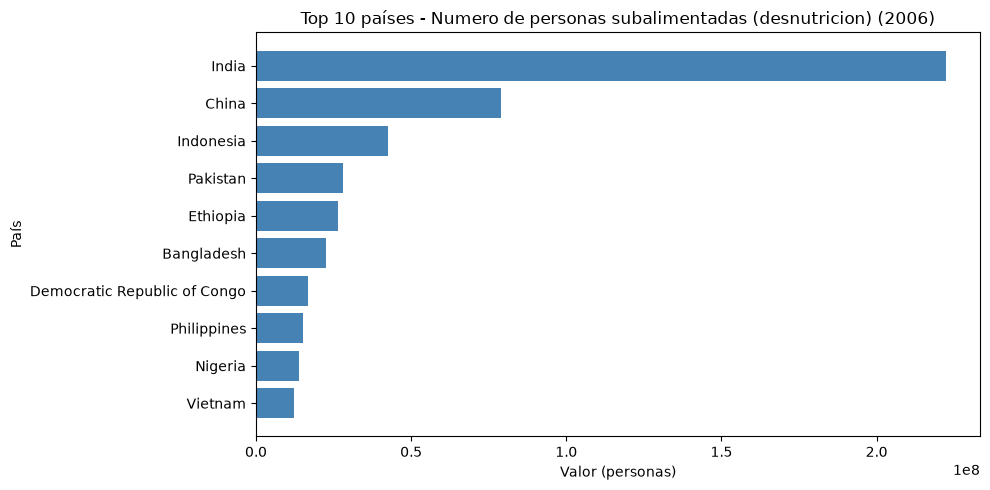

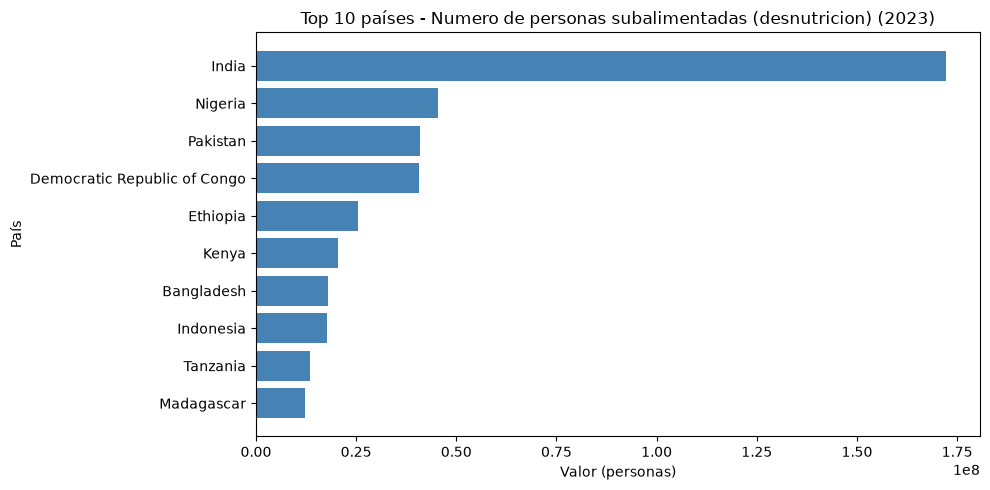

In [18]:
# Pregunta 9
anio_nacimiento = 2006
anios_grafica = [anio_nacimiento, 2023]

for anio in anios_grafica:
    top = (
        df_paises[df_paises["year"] == anio]
        .sort_values("valor", ascending=False)
        .head(10)
    )

    plt.figure(figsize=(10, 5))
    plt.barh(top["entity"], top["valor"], color="steelblue")

    plt.xlabel(f"Valor ({config['unidad']})")
    plt.ylabel("País")
    plt.title(f"Top 10 países - {config['descripcion']} ({anio})")

    plt.gca().invert_yaxis() 
    plt.tight_layout()
    plt.show()


**Interpretación:**

India se mantiene como el país con más personas subalimentadas en ambos años, aunque su cifra bajó . El movimiento más notorio es el de Nigeria: en 2006 apenas entraba al top 10 (9° lugar, 13.8 millones) y para 2023 salta al 2° lugar con 45.4 millones, más del triple. También entran países africanos que no estaban en 2006 (Kenia, Tanzania, Madagascar), mientras que China (2° lugar en 2006, con 78.8 millones), Filipinas y Vietnam salen del top 10 en 2023. En el caso de China, el dataset deja de reportar sus datos después de 2009. En conjunto, las gráficas muestran cómo el peso de la desnutrición se fue desplazando de Asia hacia África en estos años.

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

Trabajar con el dataset de desnutrición me dejó claro que hay que tener mucho cuidado al interpretar cifras absolutas: India domina casi cualquier ranking simplemente por ser el país más poblado, no necesariamente por tener el peor problema nutricional relativo, y algo similar pasa al comparar grupos de países (Latinoamérica vs. Asia). El patrón más interesante que encontré fue el desplazamiento geográfico del problema: entre 2006 y 2023 varios países africanos (Nigeria, Kenia, Tanzania, Madagascar) entraron con fuerza al top 10, mientras que países asiáticos que antes destacaban (China, Filipinas, Vietnam) salieron de él. El caso de Nigeria es el más llamativo, con un crecimiento casi ininterrumpido en dos décadas. También noté limitaciones importantes: la columna code no bastaba para filtrar agregados, porque World tenía un pseudo-código (OWID_WRL) en vez de estar vacío; y varios países (como China después de 2009, o Japón y Dinamarca, que no aparecen en absoluto) tienen datos incompletos o ausentes, probablemente porque el FAO no los reporta cuando el problema es poco significativo. Si tuviera más tiempo, normalizaría el indicador por población (por ejemplo, como porcentaje de la población total) para poder comparar países de tamaños muy distintos de forma justa, y buscaría una fuente complementaria para llenar los huecos de países como China.

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
